In [1]:
import polars as pl
from matplotlib import pyplot as plt
import seaborn as sns
import os

from polars.testing.parametric import column

os.chdir('../src')
print(os.getcwd())

/home/efran/GitHub/Spark-MLOps-Performance-Analysis/src


# Data Exploration

## Load Data and Overview

In [2]:
df = pl.read_csv("data/creditcardfraud/creditcard.csv", infer_schema_length=5000000)

# Viewing data
print("DF Head:")
display(df.head(5))
print("DF Summary:")
display(df.describe())


DF Head:


Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64
0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.5516,-0.617801,-0.99139,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
0.0,1.191857,0.266151,0.16648,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.16717,0.125895,-0.008983,0.014724,2.69,0
1.0,-1.358354,-1.340163,1.773209,0.37978,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.52498,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.1083,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.5,0
2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.11967,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.20601,0.502292,0.219422,0.215153,69.99,0


DF Summary:


statistic,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",284807.0,284807.0,284807.0,284807.0,284807.0,284807.0,284807.0,284807.0,284807.0,284807.0,284807.0,284807.0,284807.0,284807.0,284807.0,284807.0,284807.0,284807.0,284807.0,284807.0,284807.0,284807.0,284807.0,284807.0,284807.0,284807.0,284807.0,284807.0,284807.0,284807.0,284807.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",94813.859575,1.1307e-15,3.6644e-16,-1.3449e-15,2.0458e-15,1.0307e-15,1.4924e-15,-5.9047e-16,8.7818e-17,-2.3695e-15,2.2651e-15,1.6655e-15,-1.2339e-15,8.0649e-16,1.1793e-15,4.8866e-15,1.4697e-15,-3.9748e-16,9.2533e-16,1.0161e-15,6.5863e-16,1.8043e-16,-3.2952e-16,2.3222e-16,4.4567e-15,4.9697e-16,1.7068e-15,-3.5062e-16,-1.1137e-16,88.349619,0.001727
"""std""",47488.145955,1.958696,1.651309,1.516255,1.415869,1.380247,1.332271,1.237094,1.194353,1.098632,1.08885,1.020713,0.999201,0.995274,0.958596,0.915316,0.876253,0.849337,0.838176,0.814041,0.770925,0.734524,0.725702,0.62446,0.605647,0.521278,0.482227,0.403632,0.330083,250.120109,0.041527
"""min""",0.0,-56.40751,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,-24.588262,-4.797473,-18.683715,-5.791881,-19.214325,-4.498945,-14.129855,-25.162799,-9.498746,-7.213527,-54.49772,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.0,0.0
"""25%""",54202.0,-0.920372,-0.598545,-0.890358,-0.848637,-0.691592,-0.768295,-0.554068,-0.208628,-0.643096,-0.535425,-0.762491,-0.405566,-0.648535,-0.425561,-0.582882,-0.468018,-0.483745,-0.49885,-0.456291,-0.211721,-0.22839,-0.542348,-0.161846,-0.354579,-0.317143,-0.326979,-0.070839,-0.052959,5.6,0.0
"""50%""",84692.0,0.018109,0.065486,0.179846,-0.019847,-0.054336,-0.274187,0.040103,0.022358,-0.051429,-0.092917,-0.032757,0.140033,-0.013568,0.050601,0.048072,0.066413,-0.065676,-0.003636,0.003735,-0.062481,-0.02945,0.006782,-0.011193,0.040976,0.016594,-0.052139,0.001342,0.011244,22.0,0.0
"""75%""",139321.0,1.315648,0.803728,1.027201,0.743354,0.611927,0.398569,0.570446,0.327346,0.59714,0.453945,0.739596,0.61824,0.662507,0.49315,0.648823,0.523303,0.399677,0.50081,0.458951,0.133047,0.186384,0.528555,0.147642,0.439527,0.350716,0.240957,0.091046,0.078281,77.17,0.0
"""max""",172792.0,2.45493,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,23.745136,12.018913,7.848392,7.126883,10.526766,8.877742,17.315112,9.253526,5.041069,5.591971,39.420904,27.202839,10.50309,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.16,1.0


## Conduct Initial Exploration

In [3]:
print([x for x in zip(df.columns, df.dtypes)])

[('Time', Float64), ('V1', Float64), ('V2', Float64), ('V3', Float64), ('V4', Float64), ('V5', Float64), ('V6', Float64), ('V7', Float64), ('V8', Float64), ('V9', Float64), ('V10', Float64), ('V11', Float64), ('V12', Float64), ('V13', Float64), ('V14', Float64), ('V15', Float64), ('V16', Float64), ('V17', Float64), ('V18', Float64), ('V19', Float64), ('V20', Float64), ('V21', Float64), ('V22', Float64), ('V23', Float64), ('V24', Float64), ('V25', Float64), ('V26', Float64), ('V27', Float64), ('V28', Float64), ('Amount', Float64), ('Class', Int64)]


Initial Exploration Findings:
- All independent values are Floats. I don't have to worry about converting the data into values.
    - Values don't seem to have high standard variation
- 'Class' is my dependant variable. It is a binary integer value where 0 = Not Fraud and 1 = Fraud.
- There are no Null values for me to worry about --> Data has already been cleaned

## Analyzing Target

- We can see that the target value is heavily skewed. Thus when we create our training splits we need to do stratified splits

Class value counts


Class,count
i64,u32
1,492
0,284315


Class value counts normalized


Class,proportion
i64,f64
1,0.001727
0,0.998273


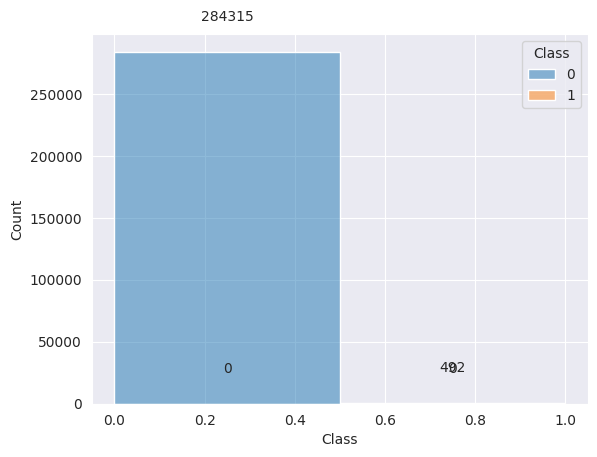

In [4]:
ax = sns.histplot(data=df, x="Class", hue="Class", bins=2)
for container in ax.containers:
    ax.bar_label(container, padding=20)

print("Class value counts")
display(df["Class"].value_counts())
print("Class value counts normalized")
display(df["Class"].value_counts(normalize=True))

## Analyzing Variables

- From the correlation we can see that the 'Class' isn't significantly correlated to any single variable
    - We can see are V11, V4, V2 are the most correlated with Fraud
    - We can see that V17, V14, V12, V10, V16, V3 are the most negatively correlated with Fraud
    - The rest of the values do not show high correlation
- We may potentially drop the ~0 correlation variables and see how that potentially impacts performance

In [10]:
corr_matrix = df.corr()
corr_matrix

Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1.0,0.117396,-0.010593,-0.419618,-0.10526,0.173072,-0.063016,0.084714,-0.036949,-0.00866,0.030617,-0.247689,0.124348,-0.065902,-0.098757,-0.183453,0.011903,-0.073297,0.090438,0.028975,-0.050866,0.044736,0.144059,0.051142,-0.016182,-0.233083,-0.041407,-0.005135,-0.009413,-0.010596,-0.012323
0.117396,1.0,-8.5650e-17,-5.6982e-16,-2.8550e-16,2.8087e-16,1.6046e-16,1.2042e-16,-6.2707e-17,3.4480e-17,4.7072e-17,2.7880e-16,1.5073e-16,-4.2047e-17,3.8916e-16,-8.9978e-17,3.8212e-16,-6.9284e-17,1.3233e-16,1.6409e-16,1.2286e-16,-9.8761e-17,7.7876e-17,1.7813e-16,-5.5647e-17,-2.6296e-16,-1.2987e-16,1.0379e-16,3.8761e-16,-0.227709,-0.101347
-0.010593,-8.5650e-17,1.0,-7.2539e-18,-1.6403e-16,1.1463e-16,3.8579e-16,-1.4015e-16,-2.3377e-17,-1.0143e-16,-1.2821e-16,3.4565e-16,-3.0005e-16,-4.0045e-17,-3.7167e-16,6.4770e-17,2.1725e-17,-6.2294e-16,2.2337e-16,9.6695e-18,1.3099e-16,8.6831e-17,1.5404e-16,1.2107e-16,-9.7238e-17,1.0822e-16,2.7074e-16,-5.1729e-16,-3.7743e-16,-0.531409,0.091289
-0.419618,-5.6982e-16,-7.2539e-18,1.0,-2.3447e-16,-5.6883e-16,1.4533e-15,2.2108e-16,-5.8412e-17,1.2889e-16,1.9076e-16,1.1445e-16,2.8758e-16,-3.2469e-17,6.4879e-16,-9.8941e-17,5.6265e-16,3.5801e-17,2.8097e-16,3.4198e-16,7.1670e-17,-1.6751e-16,-3.0731e-16,-7.9179e-17,3.3620e-17,1.0590e-16,-2.1964e-16,5.1359e-16,7.3797e-16,-0.21088,-0.192961
-0.10526,-2.8550e-16,-1.6403e-16,-2.3447e-16,1.0,-1.8415e-15,-4.2019e-16,-6.6417e-17,6.1828e-16,6.2214e-16,-1.0132e-16,-2.9252e-16,-1.9946e-16,2.6339e-17,-1.0259e-16,1.8967e-16,2.0109e-19,-3.6014e-16,-1.0827e-18,-2.8371e-16,-1.9404e-16,-6.2084e-17,2.3382e-16,2.0634e-16,1.5874e-16,6.5818e-16,-3.9865e-16,-1.2835e-16,-6.7662e-18,0.098732,0.133447
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
-0.041407,-1.2987e-16,2.7074e-16,-2.1964e-16,-3.9865e-16,3.2400e-16,-2.5893e-16,-7.8275e-16,3.6603e-18,-1.3350e-16,-3.7954e-16,-1.0911e-16,1.7652e-16,-1.3655e-16,-1.9897e-17,9.3749e-17,-4.6700e-16,2.1848e-16,2.9016e-16,5.5482e-16,-3.3454e-16,-4.8079e-16,-4.1883e-18,1.2858e-15,1.9771e-16,2.4550e-15,1.0,-2.8589e-16,-2.9026e-16,-0.003208,0.004455
-0.005135,1.0379e-16,-5.1729e-16,5.1359e-16,-1.2835e-16,4.6340e-16,-1.3035e-16,-1.9818e-16,3.2725e-16,-1.8493e-16,-3.8243e-16,-1.8142e-16,-3.1966e-16,-4.8436e-16,1.9015e-17,-1.2494e-15,8.0995e-16,6.9790e-16,2.2932e-16,-1.5530e-16,-9.9418e-16,-1.3939e-15,1.5673e-16,4.2382e-16,-3.0541e-16,-5.8840e-16,-2.8589e-16,1.0,7.7242e-18,0.028825,0.01758
-0.009413,3.8761e-16,-3.7743e-16,7.3797e-16,-6.7662e-18,-1.7733e-16,4.2147e-16,5.0763e-17,-5.6815e-16,7.9319e-16,2.4205e-16,-3.4768e-16,6.9733e-16,1.0839e-15,2.4077e-15,-1.1188e-15,6.9316e-16,-8.9818e-17,8.0193e-16,-1.3598e-15,-2.3270e-16,1.8519e-16,-5.2941e-16,1.3766e-15,-2.7389e-16,3.3109e-16,-2.9026e-16,7.7242e-18,1.0,0.010258,0.009536


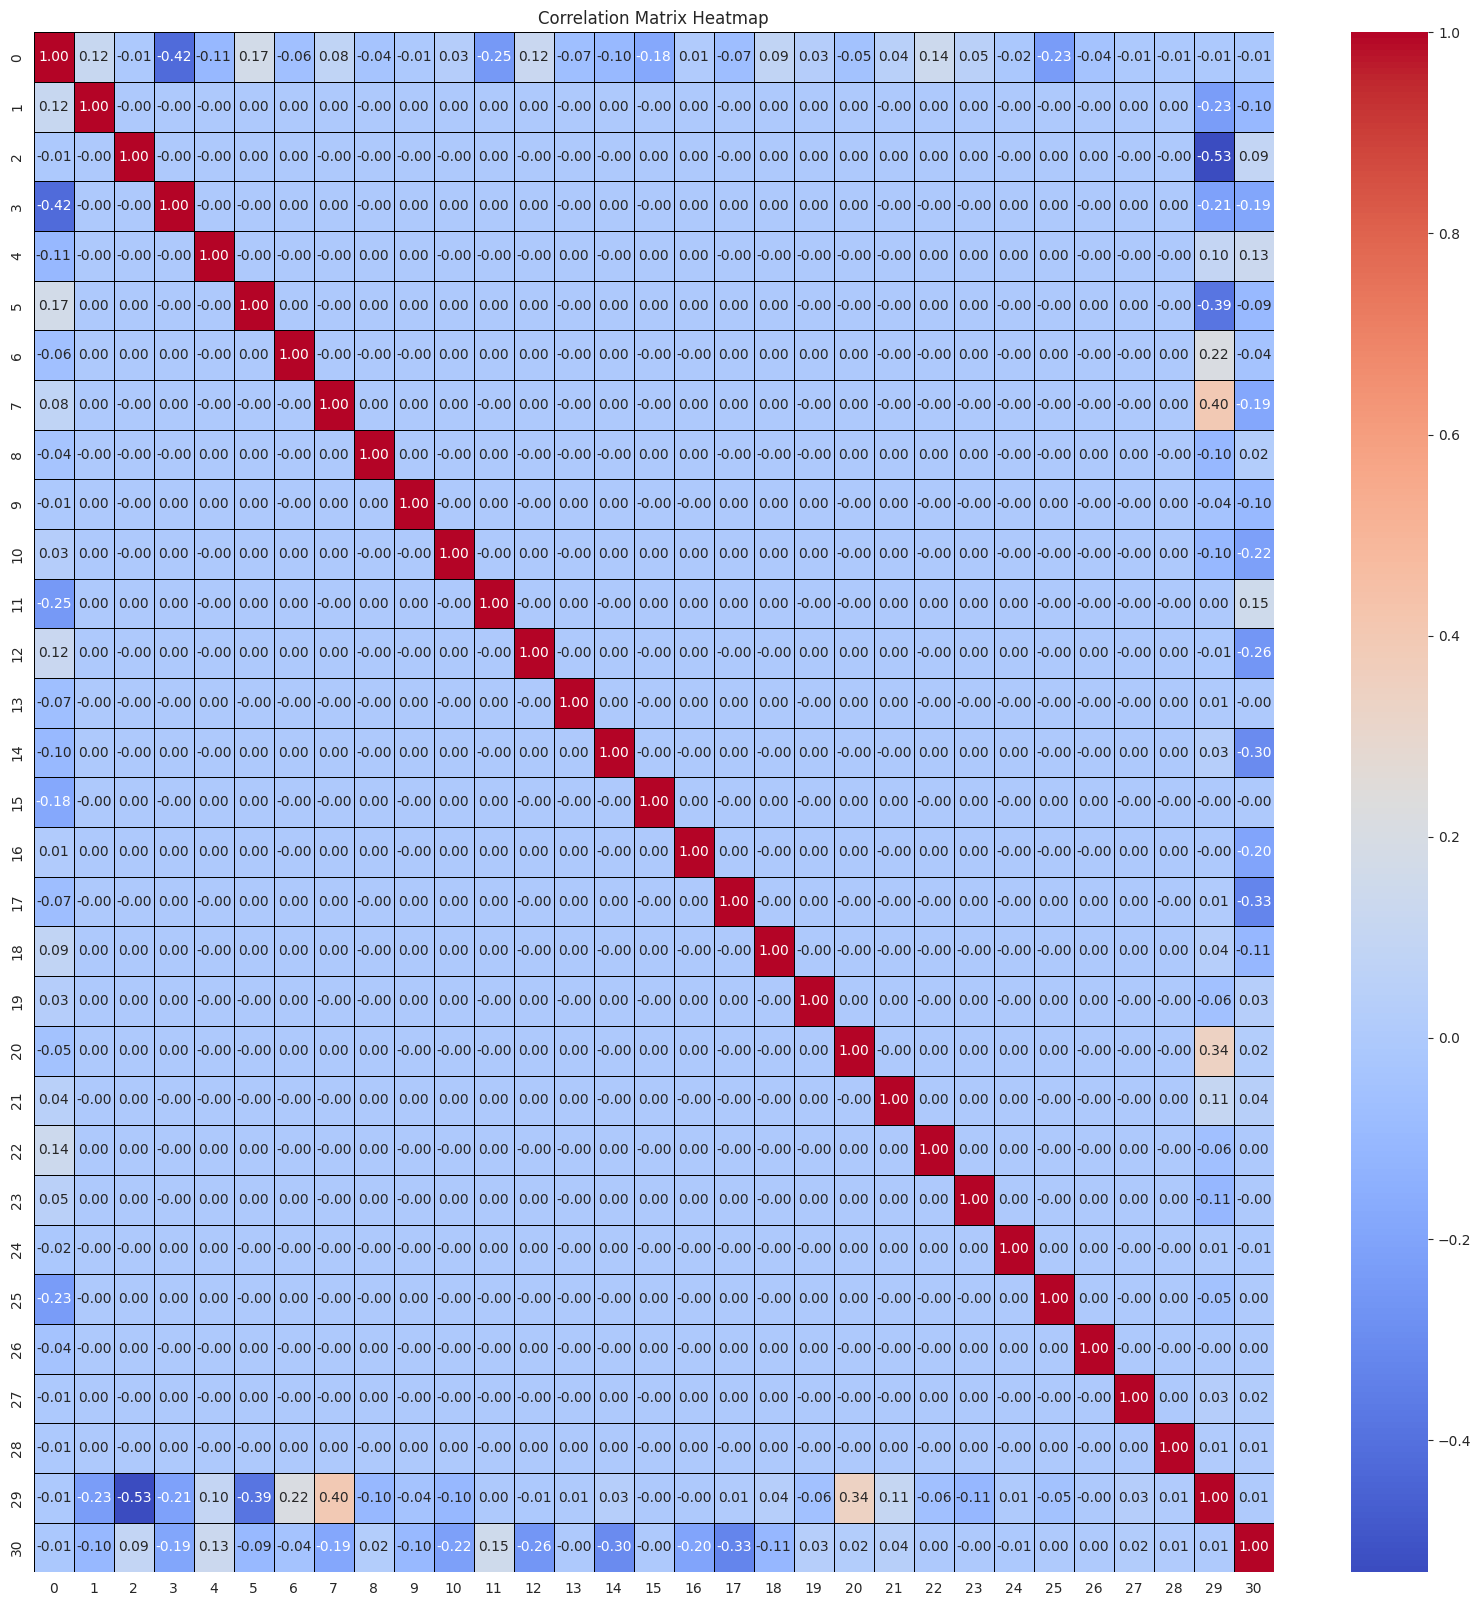

In [43]:
plt.figure(figsize=(20, 20))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f",
            linewidths=.5, linecolor='black')
plt.title('Correlation Matrix Heatmap')
plt.show()  #%%


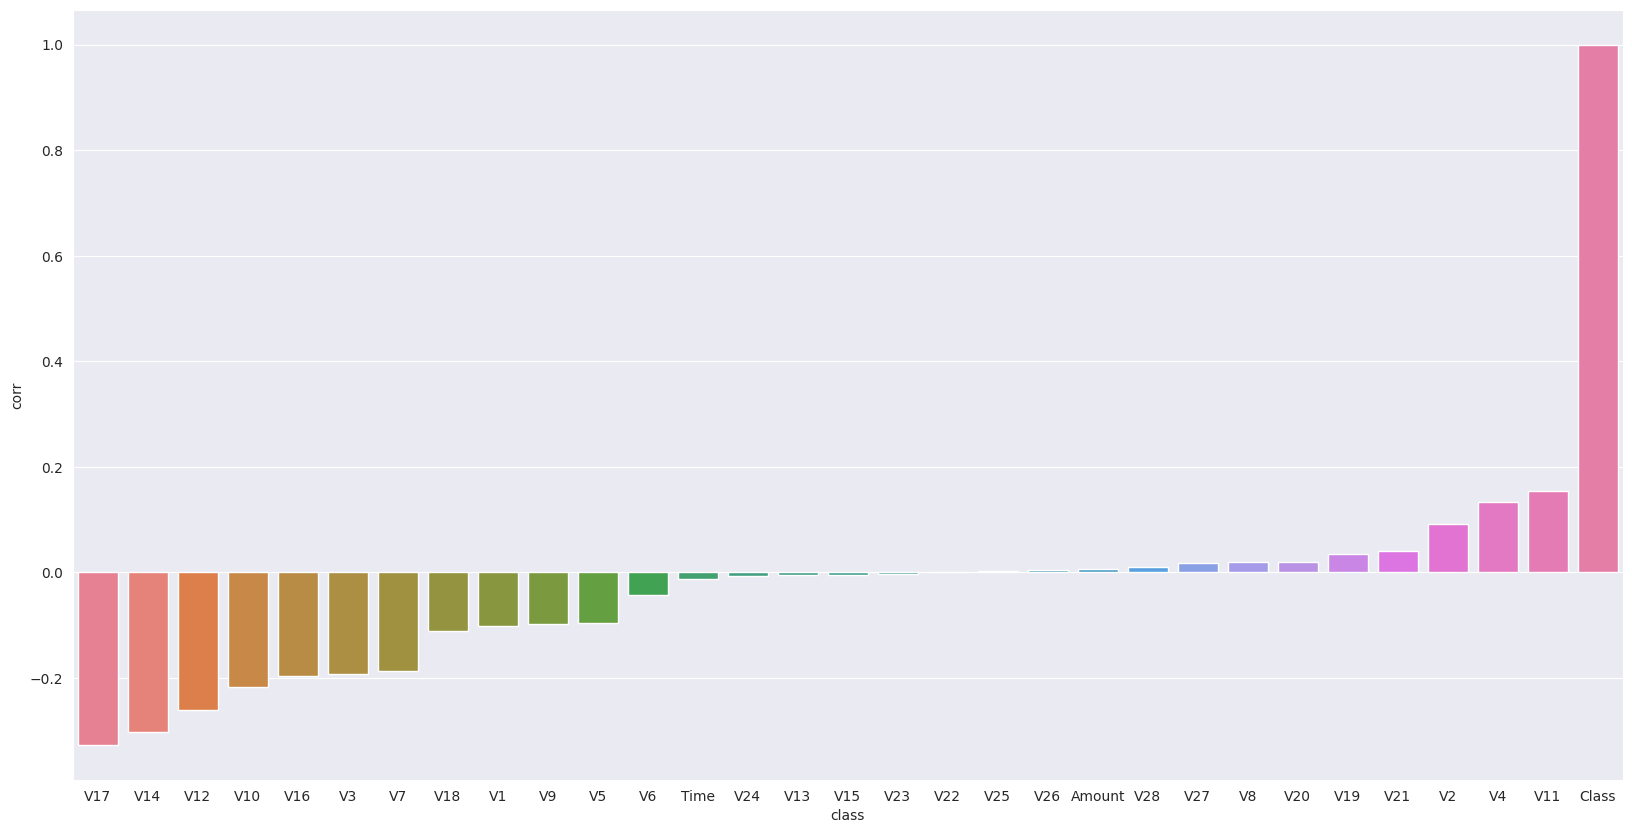

In [42]:
temp = {
    "class": corr_matrix.columns,
    "corr": list(corr_matrix["Class"])
}
fraud_corr = pl.DataFrame(temp).sort("corr")
plt.figure(figsize=(20, 10))
sns.barplot(data=fraud_corr, x="class", y="corr", hue="class")
plt.show()

## Check How Amount is Distributed Across Class

- It seems like the distribution of Amount compared to Fraud is similar so probably can't do much here

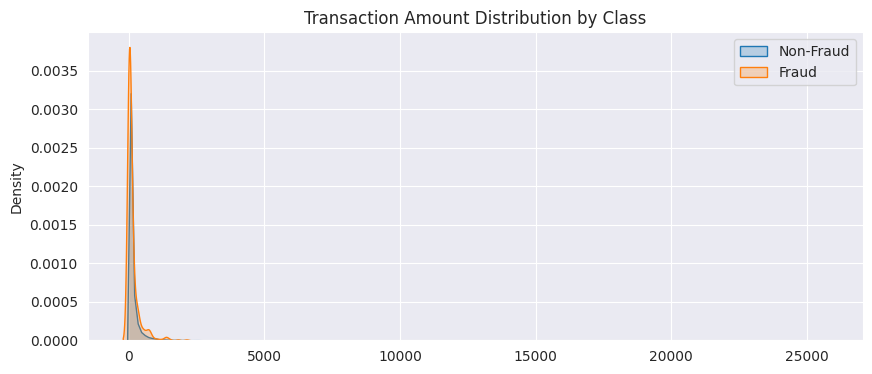

In [51]:
plt.figure(figsize=(10, 4))
sns.kdeplot(df.filter(pl.col('Class') == 0)['Amount'], label='Non-Fraud', fill=True)
sns.kdeplot(df.filter(pl.col('Class') == 1)['Amount'], label='Fraud', fill=True)
plt.title('Transaction Amount Distribution by Class')
plt.legend()
plt.show()